In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\X_train_scaled.csv"
)

X_test = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\X_test_scaled.csv"
)

y_train = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\y_train.csv"
)

y_test = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\y_test.csv"
)

print(X_train.shape)
print(X_test.shape)

(69887, 28)
(17472, 28)


## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification.

In this project, the model predicts whether a hotel booking will be cancelled (1) or not cancelled (0).

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 77.99 %


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[11774,   908],
       [ 2938,  1852]])

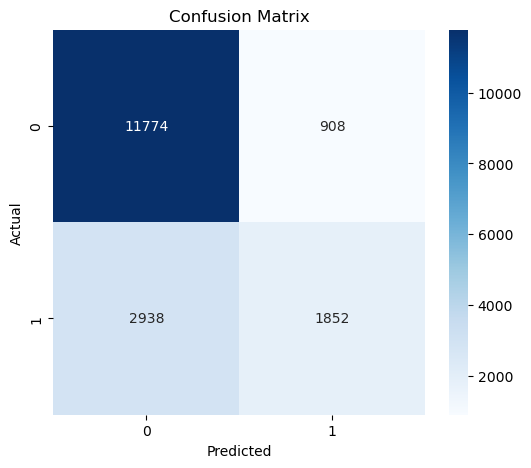

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [10]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     12682
           1       0.67      0.39      0.49      4790

    accuracy                           0.78     17472
   macro avg       0.74      0.66      0.68     17472
weighted avg       0.76      0.78      0.76     17472



In [11]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :", round(precision_score(y_test,y_pred),3))

print("Recall :", round(recall_score(y_test,y_pred),3))

print("F1 Score :", round(f1_score(y_test,y_pred),3))

Precision : 0.671
Recall : 0.387
F1 Score : 0.491


In [12]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(
    y_test,
    y_pred
)

print(
    "ROC-AUC Score:",
    round(roc,3)
)

ROC-AUC Score: 0.658


In [13]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
10,market_segment,1.038563
15,reserved_room_type,0.805254
26,has_previous_cancellation,0.546020
9,country,0.385935
1,lead_time,0.351955
20,adr,0.288286
18,deposit_type,0.288028
17,booking_changes,0.068750
4,stays_in_week_nights,0.064164
24,total_guests,0.054823


## Model Interpretation

The Logistic Regression model predicts booking cancellations using customer demographics, booking behavior, pricing information, and reservation details.

The coefficients indicate how each feature influences the likelihood of cancellation.

## Findings

- Logistic Regression model was successfully trained.
- Predictions were generated for the test dataset.
- Accuracy, Precision, Recall, F1-Score, and ROC-AUC were calculated.
- Confusion Matrix was visualized.
- Top influencing features were identified using model coefficients.

## Day 4 Conclusion

A Logistic Regression model was successfully developed to predict booking cancellations.

The model achieved satisfactory classification performance and established a baseline for comparison with more advanced models.

This baseline will be used to evaluate Decision Tree and Random Forest models in the following stages.